In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

np.random.seed(42)

In [2]:
df = pd.read_csv('C:\\Users\\\DELL\\OneDrive\\Desktop\\AI-Smart-Agriculture\\4thSem_Mini_Project\\data\\processed\\Crop_recommendation_fixed.csv')
print(df.shape)
df.head()

(2200, 9)


,N,P,K,temperature,humidity,ph,rainfall,label,disease_binary
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,At_Risk
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,At_Risk
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,At_Risk
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,At_Risk
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,At_Risk


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   N               2200 non-null   int64  
 1   P               2200 non-null   int64  
 2   K               2200 non-null   int64  
 3   temperature     2200 non-null   float64
 4   humidity        2200 non-null   float64
 5   ph              2200 non-null   float64
 6   rainfall        2200 non-null   float64
 7   label           2200 non-null   str    
 8   disease_binary  2200 non-null   str    
dtypes: float64(4), int64(3), str(2)
memory usage: 154.8 KB


In [4]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [5]:
df.isnull().sum()

N                 0
P                 0
K                 0
temperature       0
humidity          0
ph                0
rainfall          0
label             0
disease_binary    0
dtype: int64

In [6]:
high_risk_crops = {'rice', 'grapes', 'papaya', 'banana', 'coffee', 'cotton', 'apple'}
mid_risk_crops  = {'mango', 'orange', 'muskmelon', 'watermelon', 'kidneybeans', 'jute'}

In [7]:
def get_risk_score(row):
    score = 0.0

    if row['humidity'] > 85:
        score += 0.30
    elif row['humidity'] > 75:
        score += 0.15

    if row['rainfall'] > 200:
        score += 0.25
    elif row['rainfall'] > 130:
        score += 0.10

    if row['temperature'] > 35 or row['temperature'] < 15:
        score += 0.15
    elif row['temperature'] > 30:
        score += 0.05

    if row['ph'] < 5.0 or row['ph'] > 8.5:
        score += 0.20
    elif row['ph'] < 5.5 or row['ph'] > 7.8:
        score += 0.08

    if row['label'] in high_risk_crops:
        score += 0.12
    elif row['label'] in mid_risk_crops:
        score += 0.06

    return min(score, 0.90)

In [8]:
df['risk_score'] = df.apply(get_risk_score, axis=1)
df['risk_score'].describe()

count    2200.000000
mean        0.250209
std         0.174399
min         0.000000
25%         0.080000
50%         0.270000
75%         0.360000
max         0.820000
Name: risk_score, dtype: float64

In [9]:
threshold = 0.37
df['det_label'] = (df['risk_score'] >= threshold).astype(int)

In [10]:
noise = np.random.uniform(0, 1, len(df))
flip  = noise < 0.12

df['disease_binary_int'] = df['det_label'].copy()
df.loc[flip, 'disease_binary_int'] = 1 - df.loc[flip, 'det_label']

df['disease_binary'] = df['disease_binary_int'].map({1: 'At_Risk', 0: 'Healthy'})

In [11]:
print(df['disease_binary'].value_counts())
print()
print(df['disease_binary'].value_counts(normalize=True).round(3))

disease_binary
Healthy    1539
At_Risk     661
Name: count, dtype: int64

disease_binary
Healthy    0.7
At_Risk    0.3
Name: proportion, dtype: float64


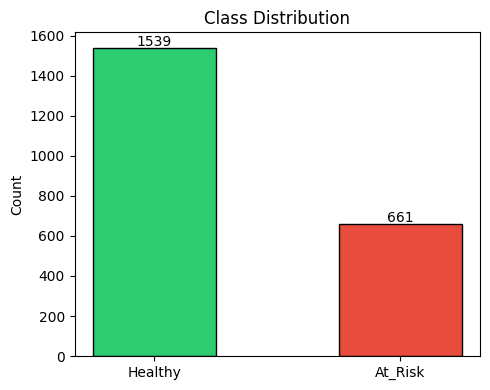

In [12]:
counts = df['disease_binary'].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
plt.title('Class Distribution')
plt.ylabel('Count')

for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

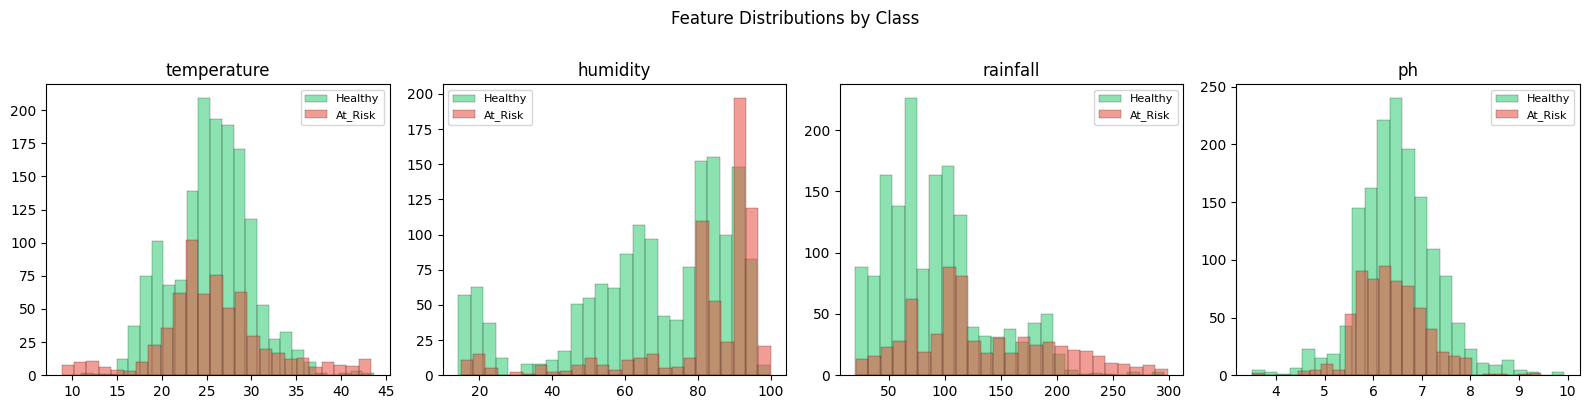

In [13]:
cols = ['temperature', 'humidity', 'rainfall', 'ph']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, cols):
    for cls, color in [('Healthy', '#2ecc71'), ('At_Risk', '#e74c3c')]:
        subset = df[df['disease_binary'] == cls][col]
        ax.hist(subset, bins=25, alpha=0.55, label=cls, color=color, edgecolor='black', linewidth=0.3)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Class', y=1.01)
plt.tight_layout()
plt.show()

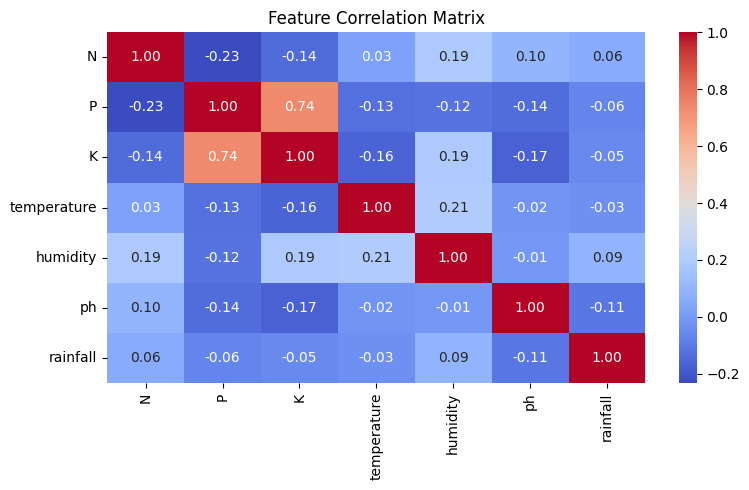

In [14]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

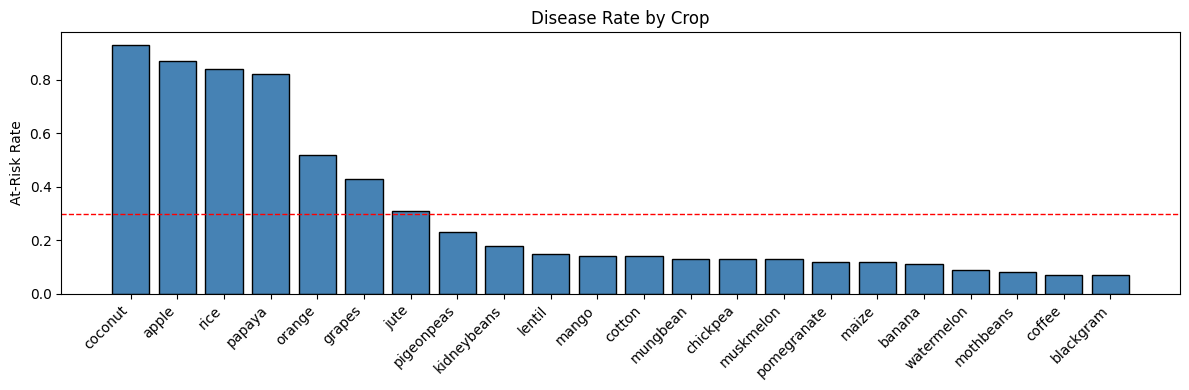

In [15]:
crop_risk = df.groupby('label')['disease_binary_int'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
plt.bar(crop_risk.index, crop_risk.values, edgecolor='black', color='steelblue')
plt.axhline(0.30, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel('At-Risk Rate')
plt.title('Disease Rate by Crop')
plt.tight_layout()
plt.show()

In [16]:
le = LabelEncoder()
df['crop_encoded'] = le.fit_transform(df['label'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


In [17]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop_encoded']

X = df[features]
y = df['disease_binary_int']

print(X.shape, y.shape)

(2200, 8) (2200,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Train:', X_train.shape)
print('Test :', X_test.shape)

Train: (1760, 8)
Test : (440, 8)


In [19]:
print('Train At_Risk:', y_train.mean().round(3))
print('Test  At_Risk:', y_test.mean().round(3))

Train At_Risk: 0.301
Test  At_Risk: 0.3


In [20]:
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [21]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

In [22]:
print(classification_report(y_test, y_pred, target_names=['Healthy', 'At_Risk']))

              precision    recall  f1-score   support

     Healthy       0.89      0.89      0.89       308
     At_Risk       0.74      0.73      0.74       132

    accuracy                           0.84       440
   macro avg       0.81      0.81      0.81       440
weighted avg       0.84      0.84      0.84       440



In [23]:
auc = roc_auc_score(y_test, y_prob)
print('ROC-AUC:', round(auc, 3))

ROC-AUC: 0.852


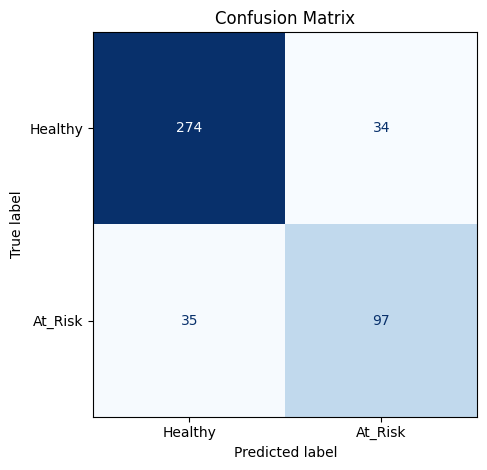

In [24]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'At_Risk'])
disp.plot(cmap='Blues', colorbar=False)

plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

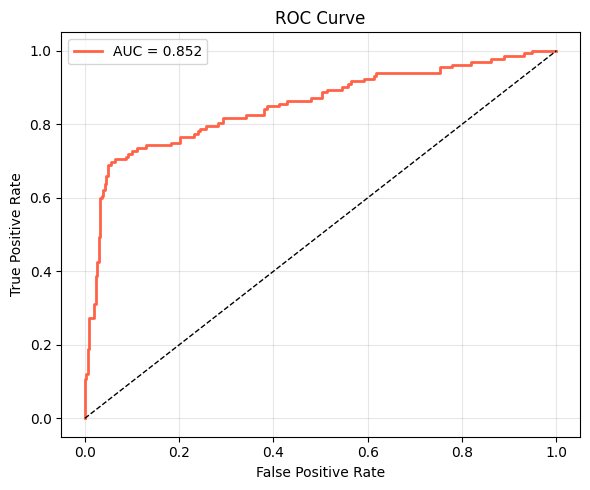

In [25]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
cv_f1  = cross_val_score(clf, X, y, cv=cv, scoring='f1')
cv_auc = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')

In [27]:
print(f'Accuracy : {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
print(f'F1 Score : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
print(f'ROC-AUC  : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')

Accuracy : 0.8464 +/- 0.0227
F1 Score : 0.7275 +/- 0.0391
ROC-AUC  : 0.8145 +/- 0.0297


C:\Users\DELL\AppData\Local\Temp\ipykernel_19416\857319148.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(list(scores.values()), labels=list(scores.keys()), patch_artist=True)


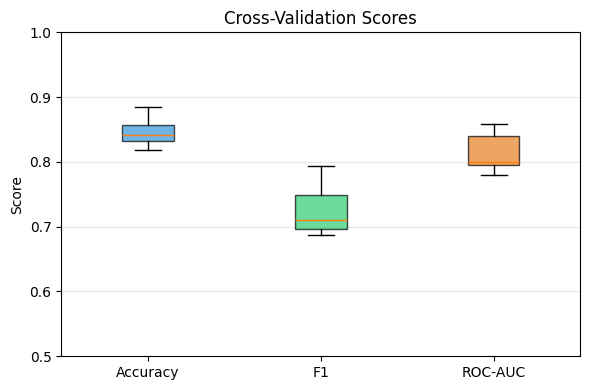

In [28]:
scores = {'Accuracy': cv_acc, 'F1': cv_f1, 'ROC-AUC': cv_auc}

plt.figure(figsize=(6, 4))
bp = plt.boxplot(list(scores.values()), labels=list(scores.keys()), patch_artist=True)

for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e67e22']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.ylim(0.5, 1.0)
plt.title('Cross-Validation Scores')
plt.ylabel('Score')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
imp = pd.DataFrame({
    'Feature'    : features,
    'Importance' : clf.feature_importances_
})

imp = imp.sort_values('Importance', ascending=False).reset_index(drop=True)
imp

,Feature,Importance
0,humidity,0.239958
1,rainfall,0.187068
2,P,0.107546
3,K,0.105485
4,crop_encoded,0.100174
5,temperature,0.096557
6,N,0.091929
7,ph,0.071283


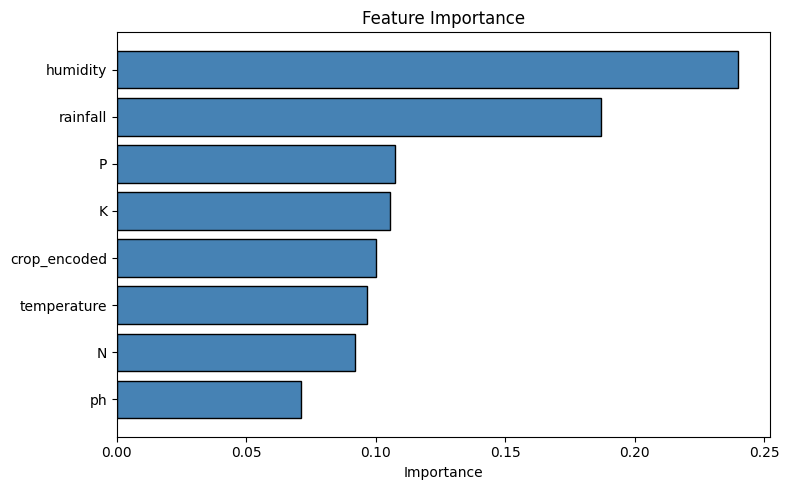

In [30]:
imp_sorted = imp.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(imp_sorted['Feature'], imp_sorted['Importance'], edgecolor='black', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [32]:
import joblib
import os

joblib.dump(clf, 'models/crop_disease_model.pkl')
print('Model saved.')
joblib.dump(le,  'models/disease_label_encoder.pkl')
print('Model saved.')

Model saved.
Model saved.
